In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dataset import _gather_labels
from config import DATA_DIR
import random
from utils import yolo2matplotlib
from extract_data import get_mappings
from math import ceil

In [38]:
def plot_random_samples(train: bool, how_many: int = 6):
    samples = _gather_labels(train)
    mapping = get_mappings(train)

    imgs_path = DATA_DIR / "train" / "images" if train else DATA_DIR / "test" / "images"
    indxs = random.sample(range(0, len(samples)), how_many)

    cols = min(3, how_many)
    rows = ceil(how_many / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))

    if rows == 1 and cols == 1:
        axs = np.array([[axs]])
    elif rows == 1 or cols == 1:
        axs = axs.reshape(rows, cols)

    for idx, img_idx in enumerate(indxs):
        row_idx = idx // cols
        col_idx = idx % cols

        curr_sample = samples[img_idx]
        img_path = imgs_path / mapping.get(curr_sample["filename"], "")

        if not img_path.exists():
            print(f"Brak pliku: {curr_sample['filename']}")
            continue

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_h, img_w, _ = img.shape

        axs[row_idx][col_idx].imshow(img)
        axs[row_idx][col_idx].axis('off')
        axs[row_idx][col_idx].grid(False)
        axs[row_idx][col_idx].set_title(f"{curr_sample["filename"]}")

        for label, bboxes in zip(curr_sample["labels"], curr_sample["bboxes"]):
            bbox_norm = yolo2matplotlib(bboxes, (img_w, img_h))
            label_name = "Fire" if label == 1 else "Smoke"
            color = "green" if label == 1 else "blue"

            rect_path = plt.Rectangle((bbox_norm[0], bbox_norm[1]), width=bbox_norm[2], height=bbox_norm[3],
                                      edgecolor=color, fill=False, linewidth=2, label=label_name)
            axs[row_idx][col_idx].text(x = bbox_norm[0] - 5, y = bbox_norm[1] - 5, s = label_name, color = "black", fontsize = "large")
            axs[row_idx][col_idx].add_patch(rect_path)

    plt.tight_layout()
    plt.show()

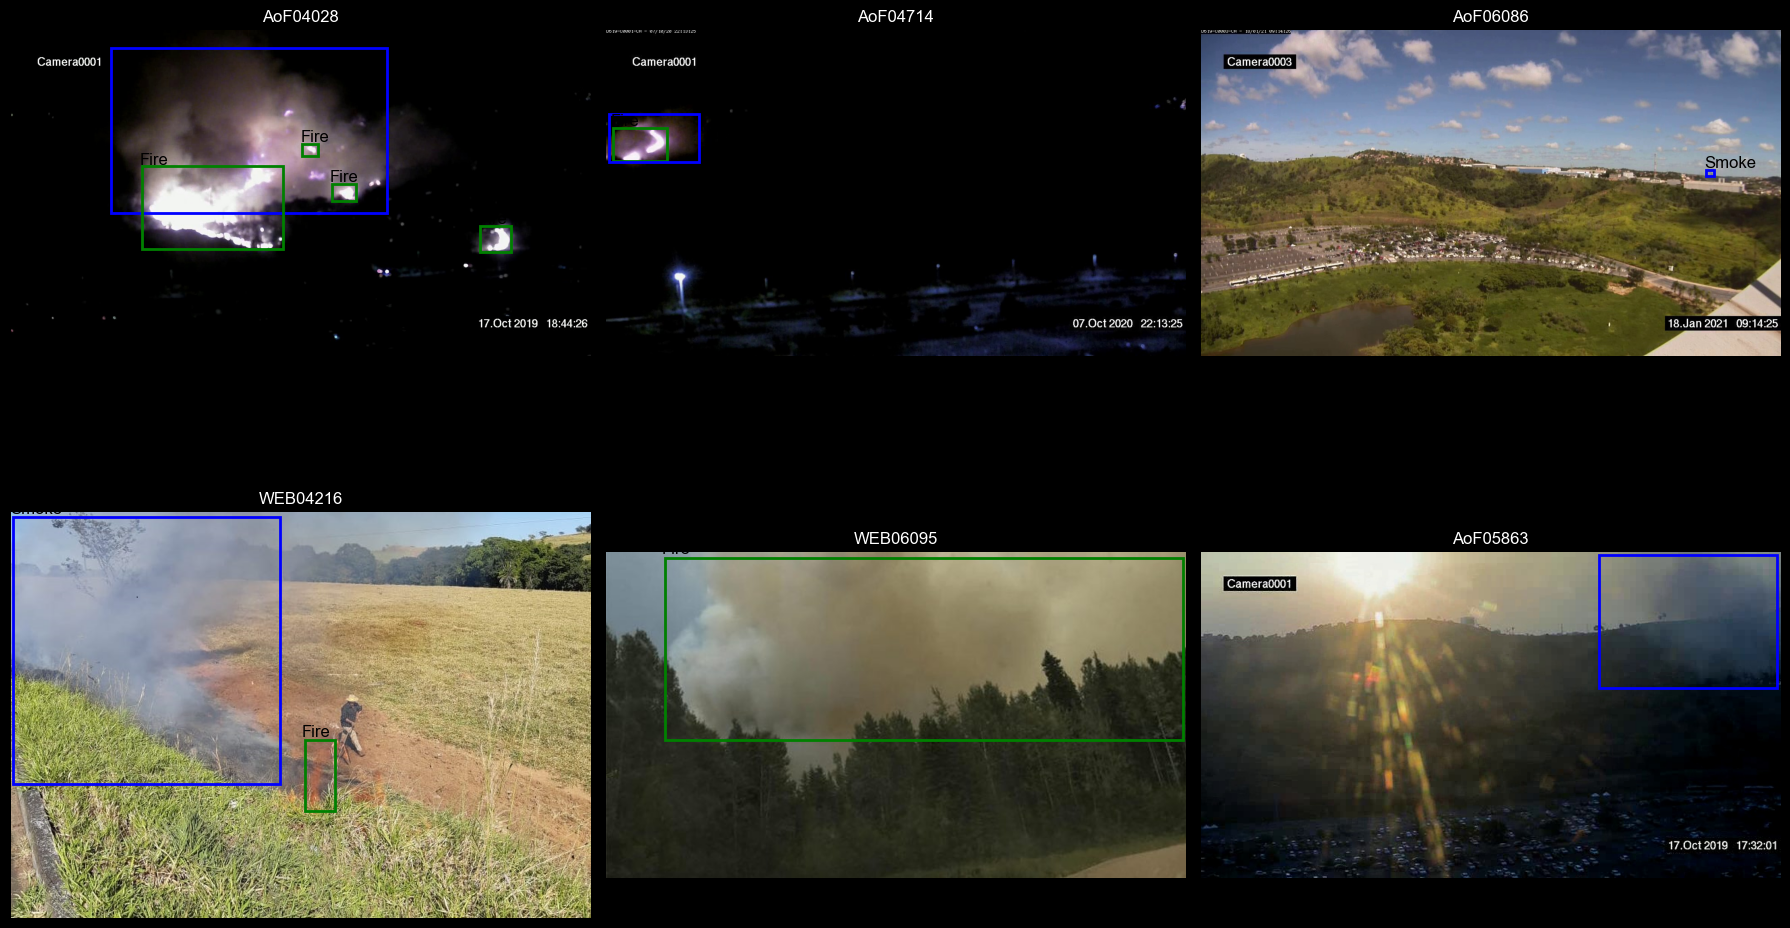

In [43]:
plot_random_samples(train=True, how_many=6)